# Statistics & Analysis

Loads classified results from CSV and visualizes class distribution and MITRE ATT&CK tactic frequencies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CSV_PATH = "/home/jovyan/data/classified_packets.csv"

df = pd.read_csv(CSV_PATH)
print(f"Total events: {len(df)}")
df.head()

Total events: 100


,event_id,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,payload_size,event_type,mitre_tactic,mitre_technique,mitre_technique_id,confidence
0,2e7f9b77-c1e6-4c2e-8c7d-151bcfe60e0b,2026-05-30T14:27:49.218721,10.0.81.60,192.168.50.58,62540,8080,ICMP,27050,brute_force,Credential Access,Brute Force,T1110,0.95
1,949bd870-f195-4c6d-be29-d3a527ca93fb,2026-05-30T14:27:49.556846,10.0.70.31,192.168.27.45,62468,8080,ICMP,3044,normal_traffic,NaN,NaN,NaN,1.00
2,8e88840a-8ff4-4bde-9d7d-93b54ae97103,2026-05-30T14:27:49.608120,10.0.10.201,192.168.67.28,4414,3306,TCP,45600,privilege_escalation,Privilege Escalation,Exploitation for Privilege Escalation,T1068,0.95
3,92f5c0e0-faf2-4fed-b6b9-0dbba3f9445c,2026-05-30T14:27:49.659507,10.0.33.35,192.168.227.201,57823,80,ICMP,6747,privilege_escalation,Privilege Escalation,Exploitation for Privilege Escalation,T1068,0.95
4,fd358c83-8f88-4a43-80a1-d254e63eced4,2026-05-30T14:27:49.710593,10.0.164.45,192.168.59.202,20709,8080,TCP,45984,c2_communication,Command and Control,Application Layer Protocol,T1071,0.95


In [3]:
print("=== Class Distribution ===")
print(df["event_type"].value_counts())

=== Class Distribution ===
event_type
brute_force             16
port_scan               16
data_exfiltration       15
c2_communication        14
lateral_movement        14
privilege_escalation    13
normal_traffic          12
Name: count, dtype: int64


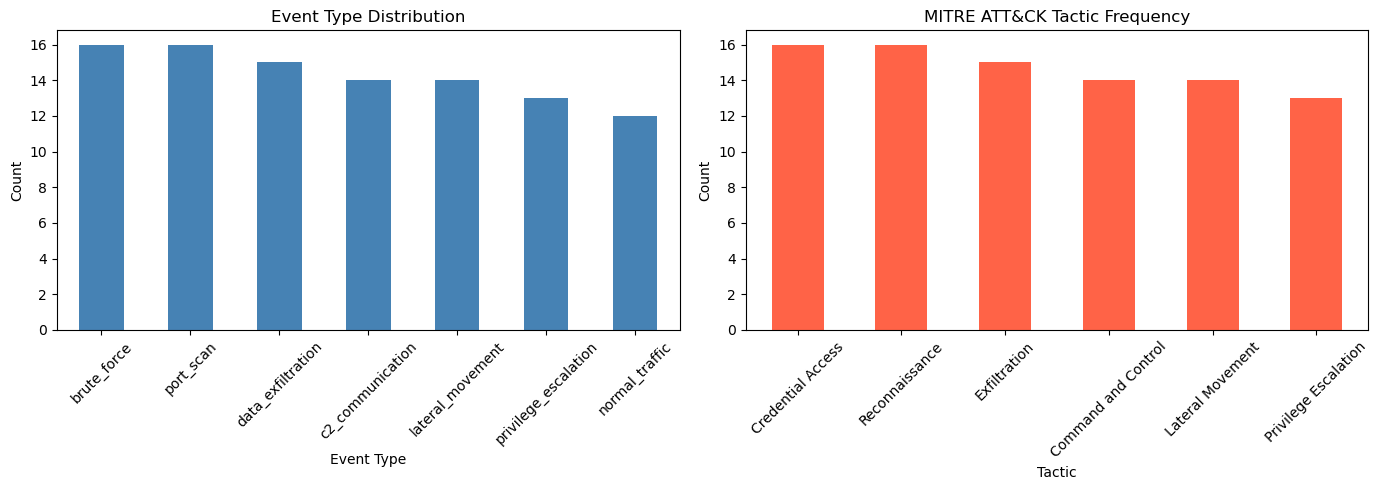

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["event_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Event Type Distribution")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

tactic_counts = df[df["mitre_tactic"] != "N/A"]["mitre_tactic"].value_counts()
tactic_counts.plot(kind="bar", ax=axes[1], color="tomato")
axes[1].set_title("MITRE ATT&CK Tactic Frequency")
axes[1].set_xlabel("Tactic")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [5]:
print("=== MITRE Technique Breakdown ===")
print(df.groupby(["mitre_tactic", "mitre_technique", "mitre_technique_id"]).size().reset_index(name="count").to_string(index=False))

=== MITRE Technique Breakdown ===
        mitre_tactic                       mitre_technique mitre_technique_id  count
 Command and Control            Application Layer Protocol              T1071     14
   Credential Access                           Brute Force              T1110     16
        Exfiltration          Exfiltration Over C2 Channel              T1041     15
    Lateral Movement                       Remote Services              T1021     14
Privilege Escalation Exploitation for Privilege Escalation              T1068     13
      Reconnaissance                       Active Scanning              T1595     16
